In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
import sqlite3
import scipy.stats as ttest_ind

In [2]:
import urllib
from sqlalchemy import create_engine
from sqlalchemy.types import String
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=KHUSHI-GUPTA\\SQLEXPRESS;"
    "DATABASE=Vendor_Management_System;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True
)


In [3]:
df=pd.read_sql_query("SELECT * from vendor_sales_summary", engine)

In [4]:
df.shape

(32076, 18)

In [5]:
df.isnull().sum()

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
GrossProfit              0
ProfitMargin             0
StockTurnover            0
SalesToPurchaseRatio     0
dtype: int64

# Exploratory Data Analysis

Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis

In [6]:
#Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,32076.0,10650.649458,18752.934461,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,32076.0,18039.228769,12661.792300,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,32076.0,24.385303,109.265968,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,32076.0,35.643671,148.241394,0.49,10.9900,15.990,28.9900,7499.99
Volume,32076.0,847.360456,664.288597,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,32076.0,3140.886831,11094.740853,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,32076.0,30106.693386,123063.962885,0.71,453.4575,3655.465,20738.2450,3811251.50
TotalSalesQuantity,32076.0,3077.482136,10952.509909,0.00,33.0000,261.000,1929.2500,334939.00
TotalSalesDollars,32076.0,42239.074473,167650.039497,0.00,729.2200,5298.045,28396.9150,5101919.50
TotalSalesPrice,32076.0,18793.783640,44951.371886,0.00,289.7100,2857.800,16059.5625,672819.25


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32076 entries, 0 to 32075
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           32076 non-null  int64  
 1   VendorName             32076 non-null  object 
 2   Brand                  32076 non-null  int64  
 3   Description            32076 non-null  object 
 4   PurchasePrice          32076 non-null  float64
 5   ActualPrice            32076 non-null  float64
 6   Volume                 32076 non-null  int64  
 7   TotalPurchaseQuantity  32076 non-null  int64  
 8   TotalPurchaseDollars   32076 non-null  float64
 9   TotalSalesQuantity     32076 non-null  int64  
 10  TotalSalesDollars      32076 non-null  float64
 11  TotalSalesPrice        32076 non-null  float64
 12  TotalExciseTax         32076 non-null  float64
 13  FreightCost            32076 non-null  float64
 14  GrossProfit            32076 non-null  float64
 15  Pr

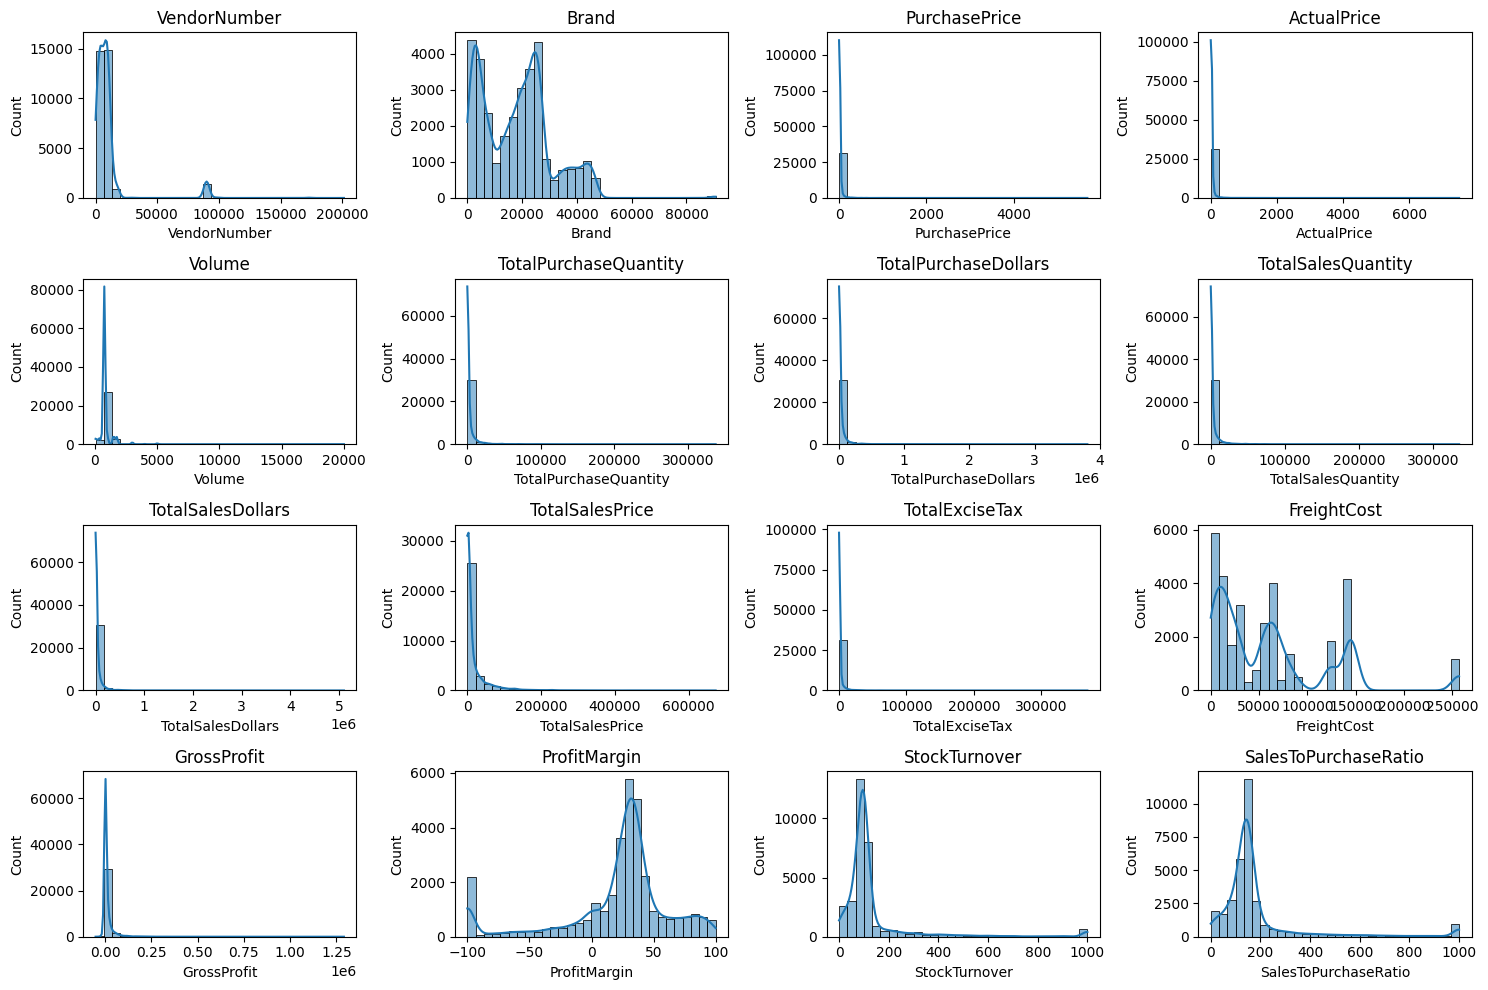

In [8]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


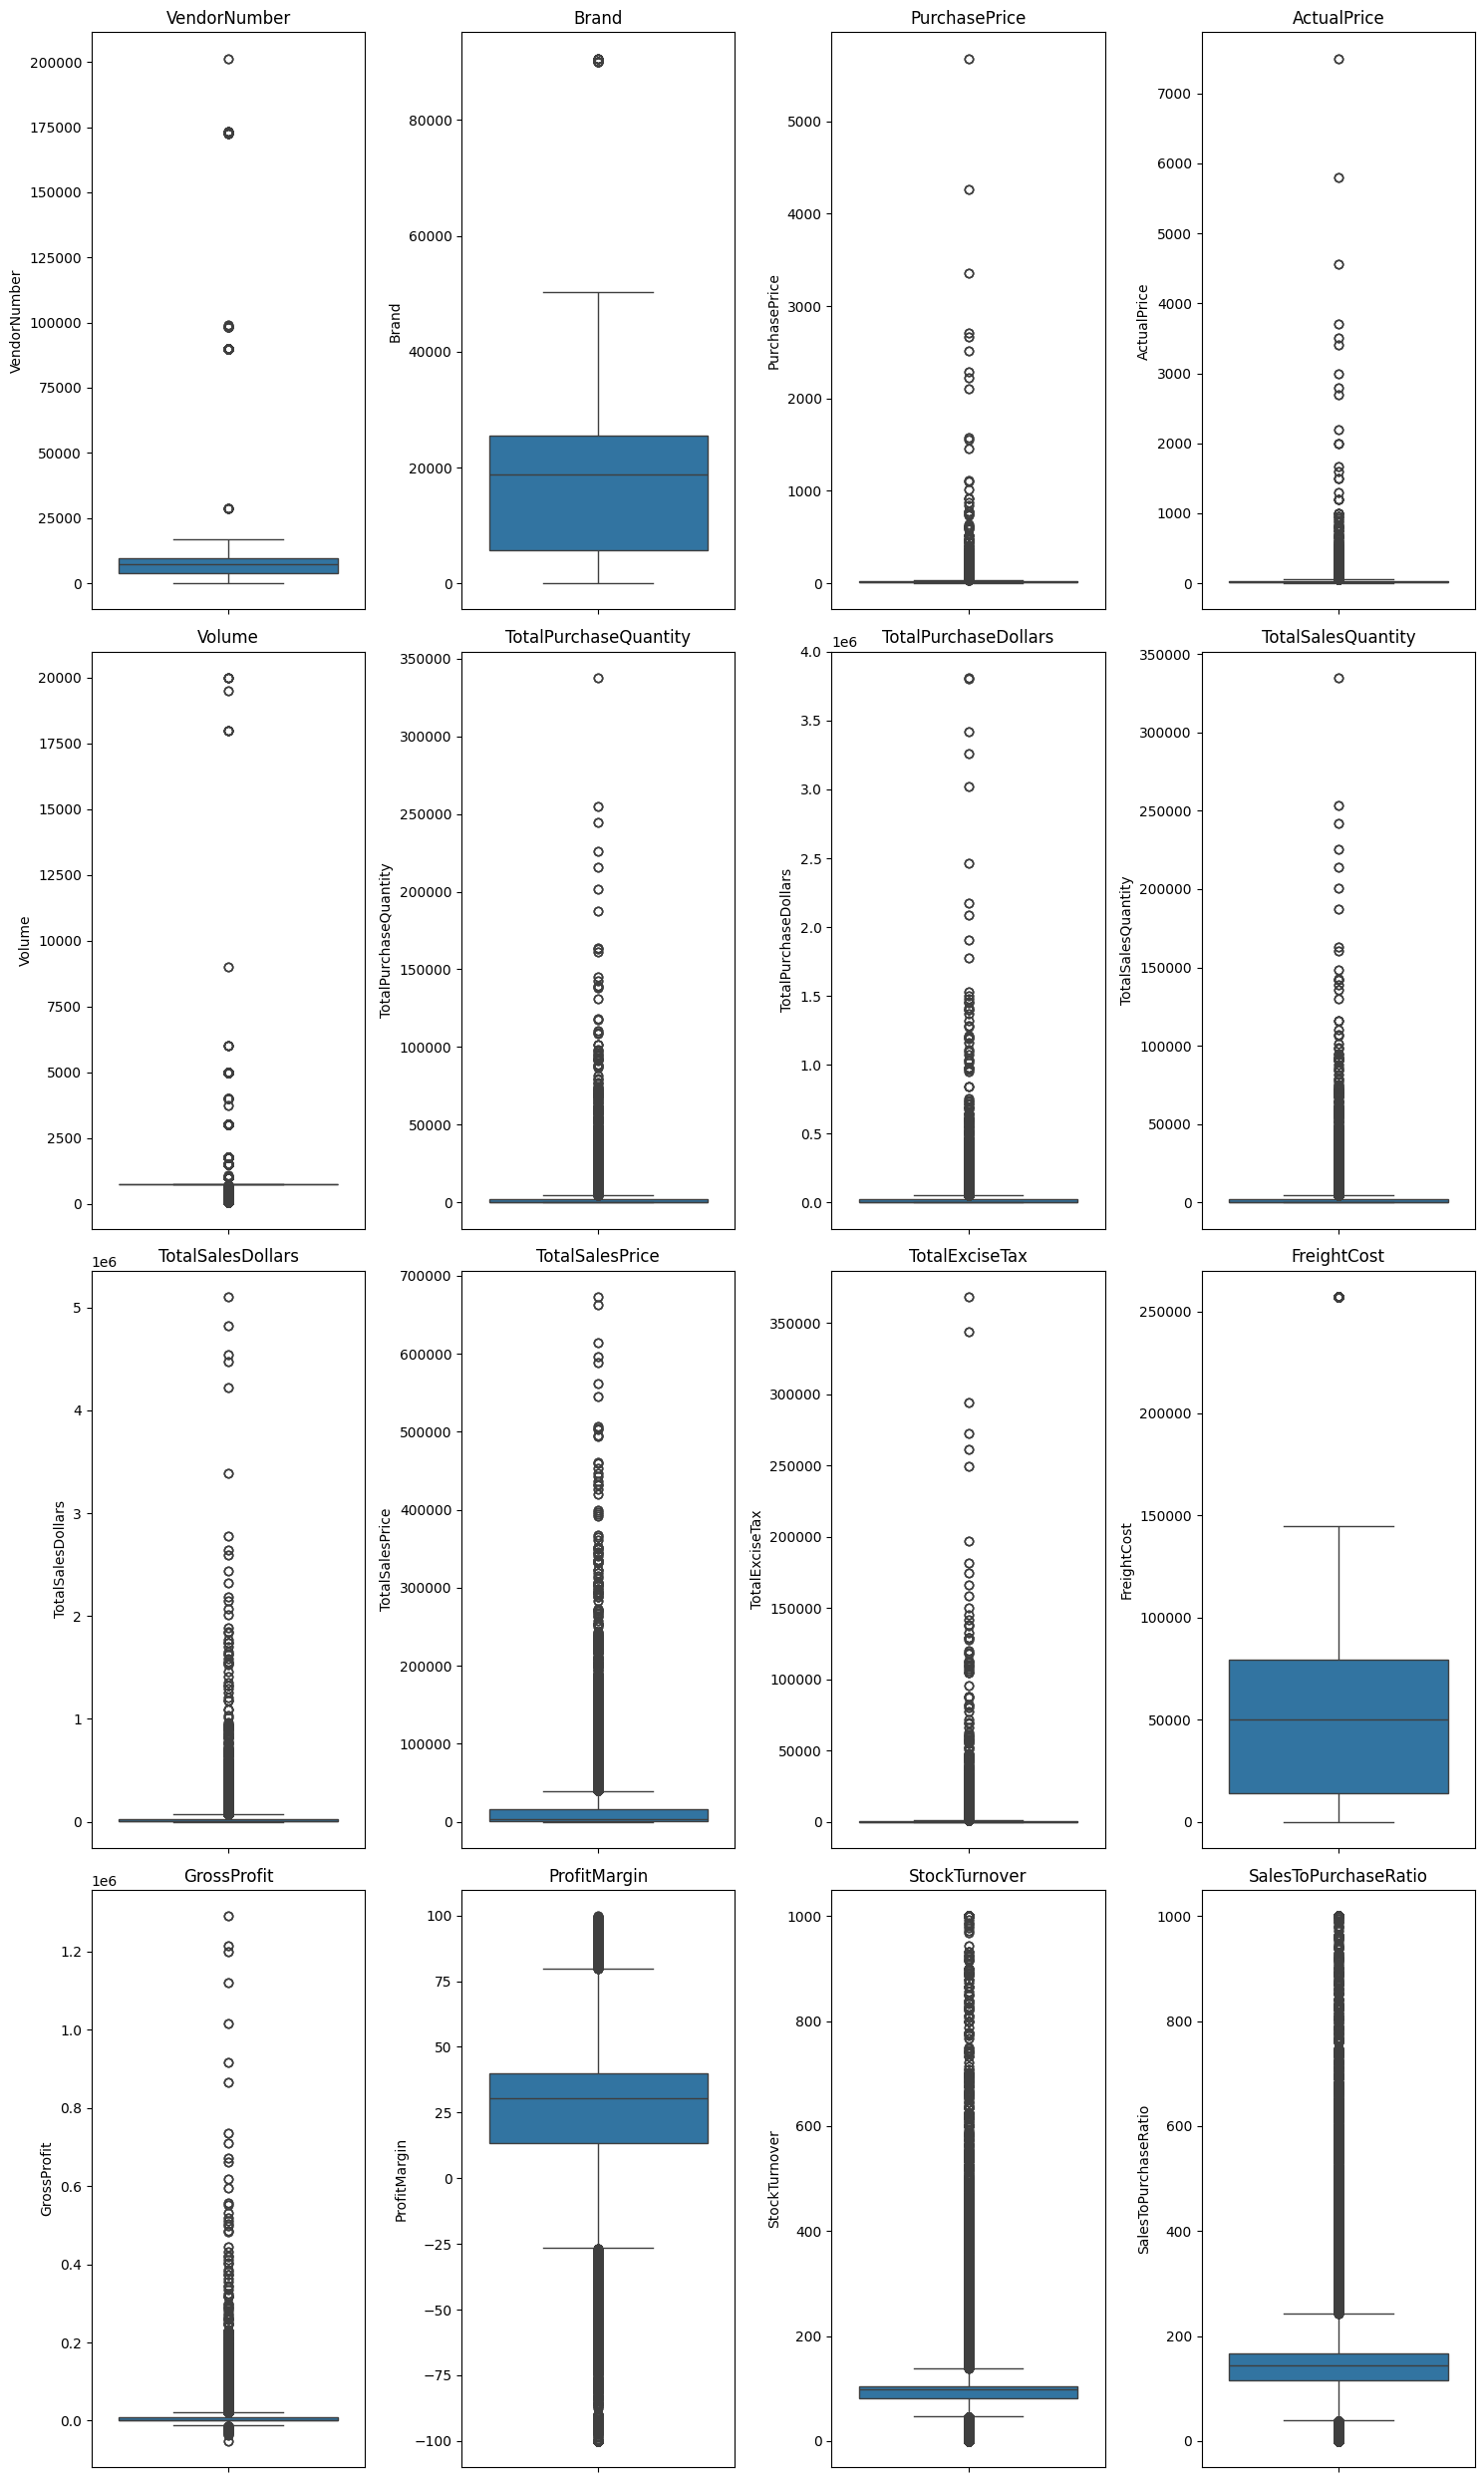

In [9]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,25))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # Adjust grid layout as needed
    sns.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


<Axes: >

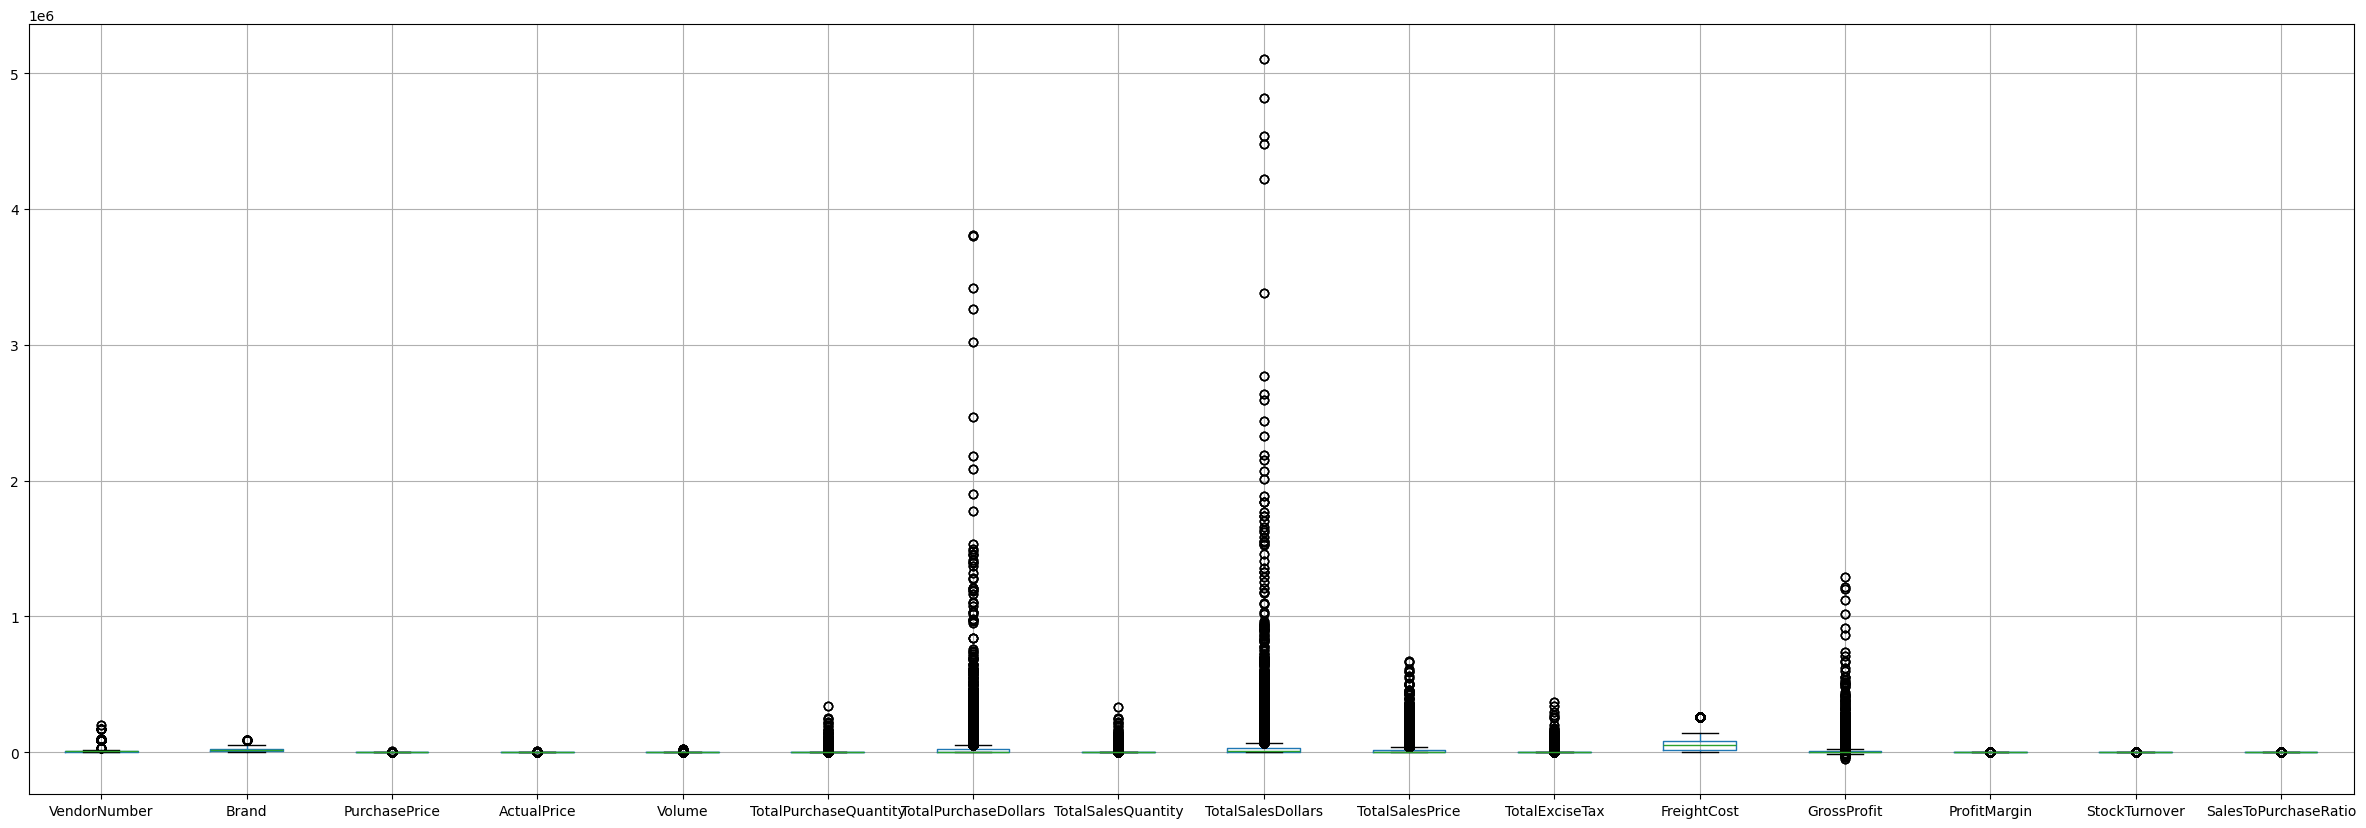

In [10]:
plt.figure(figsize=(30,10))
df.boxplot()

# Summary Statistics Insights:
# Negative & Zero Values:

Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or being sold at discounts lower than the purchase price.

Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.

Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

# Outliers Indicated by High Standard Deviations:

Purchase & Actual Prices: The maximum values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. A value greater than 1 indicates that the sold quantity for that product is higher than the purchased quantity, possibly due to sales being fulfilled from older stock.

In [11]:
df=pd.read_sql_query(
"""select * 
from vendor_sales_summary
where grossprofit>0 and
profitmargin>0 and 
totalsalesquantity>0""",engine)

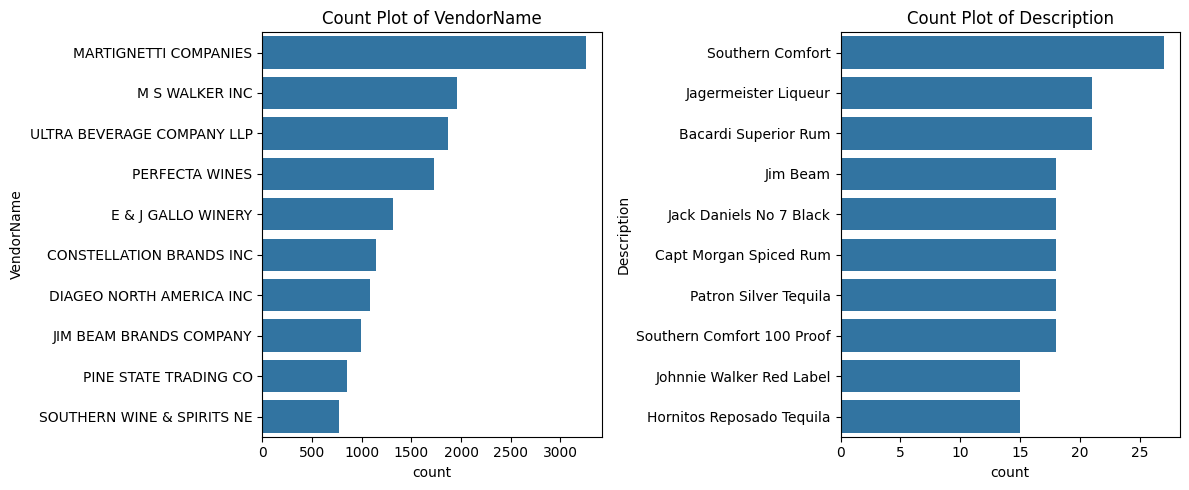

In [12]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

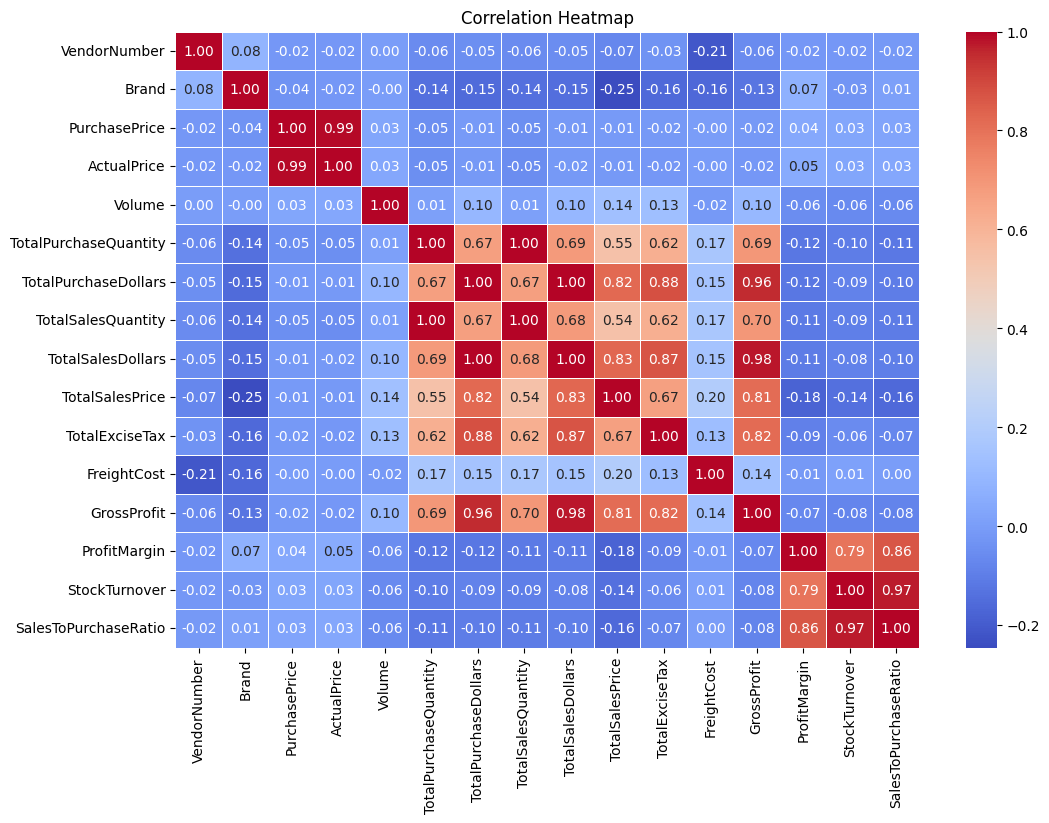

In [13]:
 # Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights

PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# DATA ANALYSIS
Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins

In [14]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [15]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [16]:
low_sales_threshold

np.float64(1680.897)

In [17]:
high_margin_threshold

np.float64(64.96799999999995)

In [18]:
#filter brands with low sales but high profit margins
target_brands=brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold)&
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]
print("Brands with low sales but high profit margins :")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins :


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,29.97,66.47
2369,Debauchery Pnt Nr,34.74,65.98
2070,Concannon Glen Ellen Wh Zin,47.85,83.45
2188,Crown Royal Apple,83.58,89.81
6237,Sauza Sprklg Wild Berry Marg,83.88,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,1607.04,76.75
2271,Dad's Hat Rye Whiskey,1616.67,81.85
57,A Bichot Clos Marechaudes,1619.82,67.74
6245,Sbragia Home Ranch Merlot,1649.25,66.44


In [19]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<1000]

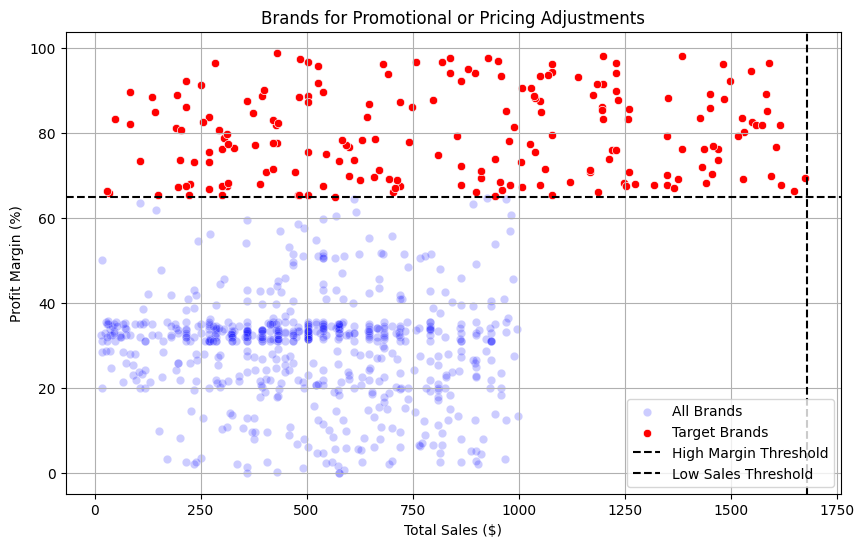

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

# Which vendor and brand demonstrate the highest sales performance 

In [21]:
def format_dollars(value):
    if value>1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}M"
    else:
        return str(value)
        

In [22]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)


In [23]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      2.039703e+08
MARTIGNETTI COMPANIES         1.179911e+08
PERNOD RICARD USA             9.618959e+07
JIM BEAM BRANDS COMPANY       9.426906e+07
BACARDI USA INC               7.456445e+07
CONSTELLATION BRANDS INC      7.265624e+07
E & J GALLO WINERY            5.519970e+07
BROWN-FORMAN CORP             5.474169e+07
ULTRA BEVERAGE COMPANY LLP    4.950763e+07
M S WALKER INC                4.411938e+07
Name: TotalSalesDollars, dtype: float64

In [24]:
top_brands

Description
Jack Daniels No 7 Black    23894240.37
Tito's Handmade Vodka      22198973.07
Grey Goose Vodka           21628825.14
Capt Morgan Spiced Rum     19068962.22
Absolut 80 Proof           18734255.70
Jameson Irish Whiskey      17147278.98
Ketel One Vodka            15210250.35
Baileys Irish Cream        12450366.48
Kahlua                     10814575.74
Tanqueray                  10370093.91
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands.apply(lambda x :  format_dollars(x))


Description
Jack Daniels No 7 Black    23.89M
Tito's Handmade Vodka      22.20M
Grey Goose Vodka           21.63M
Capt Morgan Spiced Rum     19.07M
Absolut 80 Proof           18.73M
Jameson Irish Whiskey      17.15M
Ketel One Vodka            15.21M
Baileys Irish Cream        12.45M
Kahlua                     10.81M
Tanqueray                  10.37M
Name: TotalSalesDollars, dtype: object

In [26]:
top_vendors.apply(lambda x :  format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      203.97M
MARTIGNETTI COMPANIES         117.99M
PERNOD RICARD USA              96.19M
JIM BEAM BRANDS COMPANY        94.27M
BACARDI USA INC                74.56M
CONSTELLATION BRANDS INC       72.66M
E & J GALLO WINERY             55.20M
BROWN-FORMAN CORP              54.74M
ULTRA BEVERAGE COMPANY LLP     49.51M
M S WALKER INC                 44.12M
Name: TotalSalesDollars, dtype: object

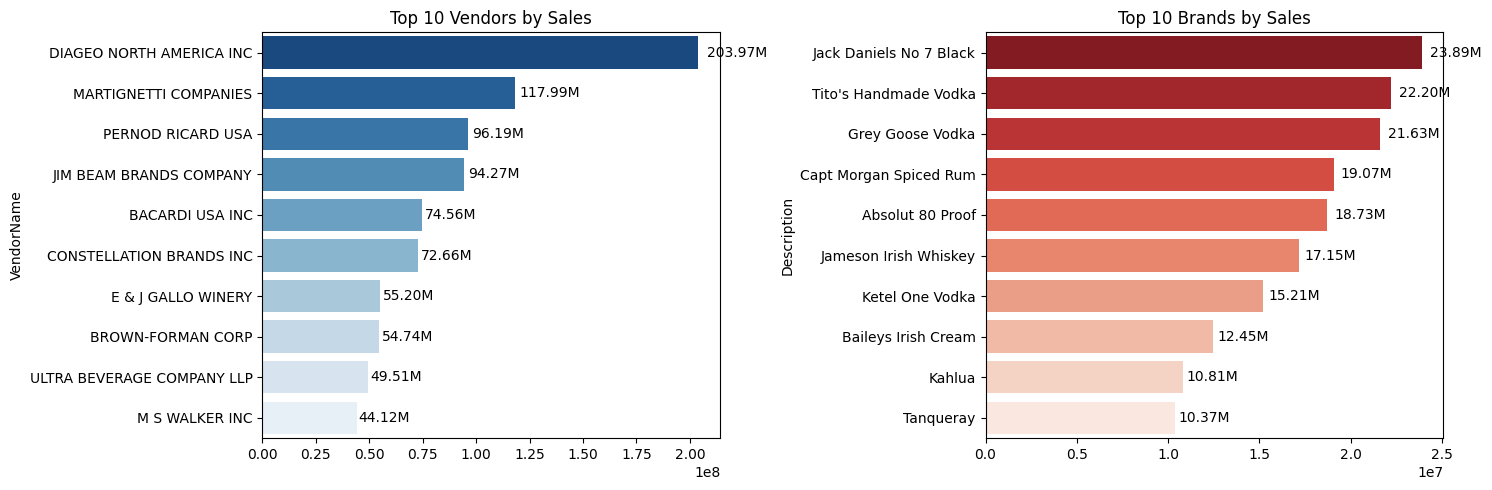

In [27]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )
plt.tight_layout()
plt.show()

# WHICH VENDOR CONTRIBUTE THE MOST TO TOTAL PURCHASE DOLLARS?

In [28]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [29]:
vendor_performance['PurchaseContribution']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [30]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution
0,ADAMBA IMPORTS INTL INC,1338.48,775.11,2113.59,0.000001
1,ALISA CARR BEVERAGES,77094.36,236318.46,313412.82,0.000084
2,ALTAMAR BRANDS LLC,35118.60,12001.83,47120.43,0.000038
3,AMERICAN SPIRITS EXCHANGE,2802.24,1731.24,4533.48,0.000003
4,AMERICAN VINTAGE BEVERAGE,313307.04,105503.55,418810.59,0.000340
...,...,...,...,...,...
114,WEIN BAUER INC,128083.92,40567.47,168651.39,0.000139
115,WESTERN SPIRITS BEVERAGE CO,895250.58,320513.91,1215764.49,0.000971
116,WILLIAM GRANT & SONS INC,17629614.69,5080013.73,22709628.75,0.019121
117,WINE GROUP INC,15611403.51,9300726.30,24912129.84,0.016932


In [31]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution',ascending=False),2)

In [32]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution
25,DIAGEO NORTH AMERICA INC,150.29M,53.68M,203.97M,0.16
57,MARTIGNETTI COMPANIES,76.51M,41.48M,117.99M,0.08
68,PERNOD RICARD USA,71.55M,24.64M,96.19M,0.08
46,JIM BEAM BRANDS COMPANY,70.48M,23.79M,94.27M,0.08
6,BACARDI USA INC,52.30M,22.27M,74.56M,0.06
20,CONSTELLATION BRANDS INC,45.82M,26.84M,72.66M,0.05
11,BROWN-FORMAN CORP,39.72M,15.02M,54.74M,0.04
30,E & J GALLO WINERY,36.21M,18.99M,55.20M,0.04
106,ULTRA BEVERAGE COMPANY LLP,33.50M,16.01M,49.51M,0.04
53,M S WALKER INC,29.29M,14.83M,44.12M,0.03


In [33]:
vendor_performance.shape

(119, 5)

In [34]:
top_vendors['PurchaseContribution'].sum()

np.float64(0.6600000000000001)

In [35]:
#RUNNING TOTAL
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution'].cumsum()

In [36]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,150.29M,53.68M,203.97M,0.16,0.16
57,MARTIGNETTI COMPANIES,76.51M,41.48M,117.99M,0.08,0.24
68,PERNOD RICARD USA,71.55M,24.64M,96.19M,0.08,0.32
46,JIM BEAM BRANDS COMPANY,70.48M,23.79M,94.27M,0.08,0.40
6,BACARDI USA INC,52.30M,22.27M,74.56M,0.06,0.46
20,CONSTELLATION BRANDS INC,45.82M,26.84M,72.66M,0.05,0.51
11,BROWN-FORMAN CORP,39.72M,15.02M,54.74M,0.04,0.55
30,E & J GALLO WINERY,36.21M,18.99M,55.20M,0.04,0.59
106,ULTRA BEVERAGE COMPANY LLP,33.50M,16.01M,49.51M,0.04,0.63
53,M S WALKER INC,29.29M,14.83M,44.12M,0.03,0.66


In [37]:
vendor_performance['PurchaseContribution']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [38]:
# Convert the decimal columns to percentages (0-100 scale)
top_vendors['PurchaseContribution'] = top_vendors['PurchaseContribution'] * 100
top_vendors['Cumulative_Contribution%'] = top_vendors['Cumulative_Contribution%'] * 100



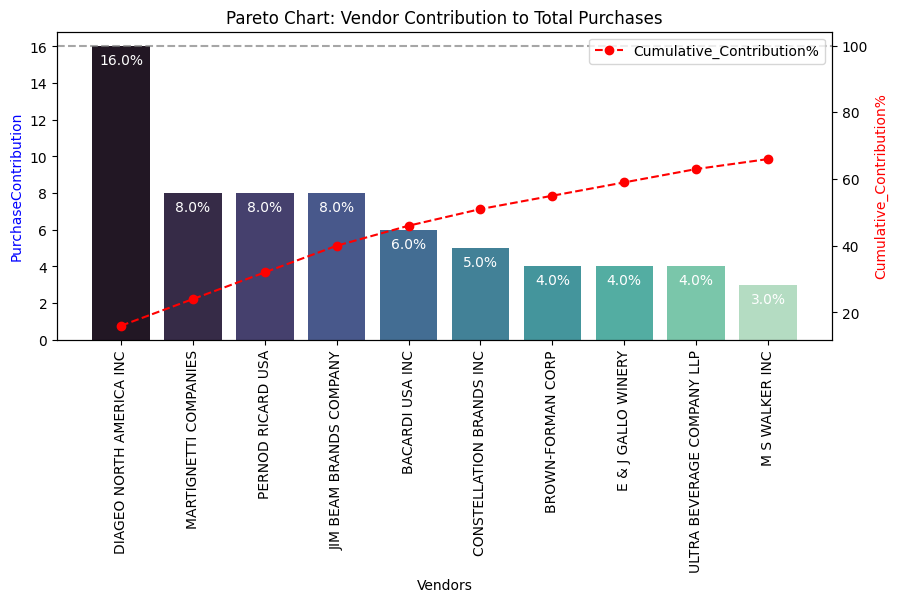

In [39]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative_Contribution%'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('PurchaseContribution', color='blue')
ax2.set_ylabel('Cumulative_Contribution%', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()


# How much of total procurement is dependent on the top vendors

In [40]:
round(top_vendors['PurchaseContribution'].sum()*100,2)

np.float64(6600.0)

In [41]:
# Convert the column to percentage format (0-100 scale)
top_vendors['PurchaseContribution'] = top_vendors['PurchaseContribution'] * 100

# Now run your existing code...
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution'].values)
# ... rest of your code

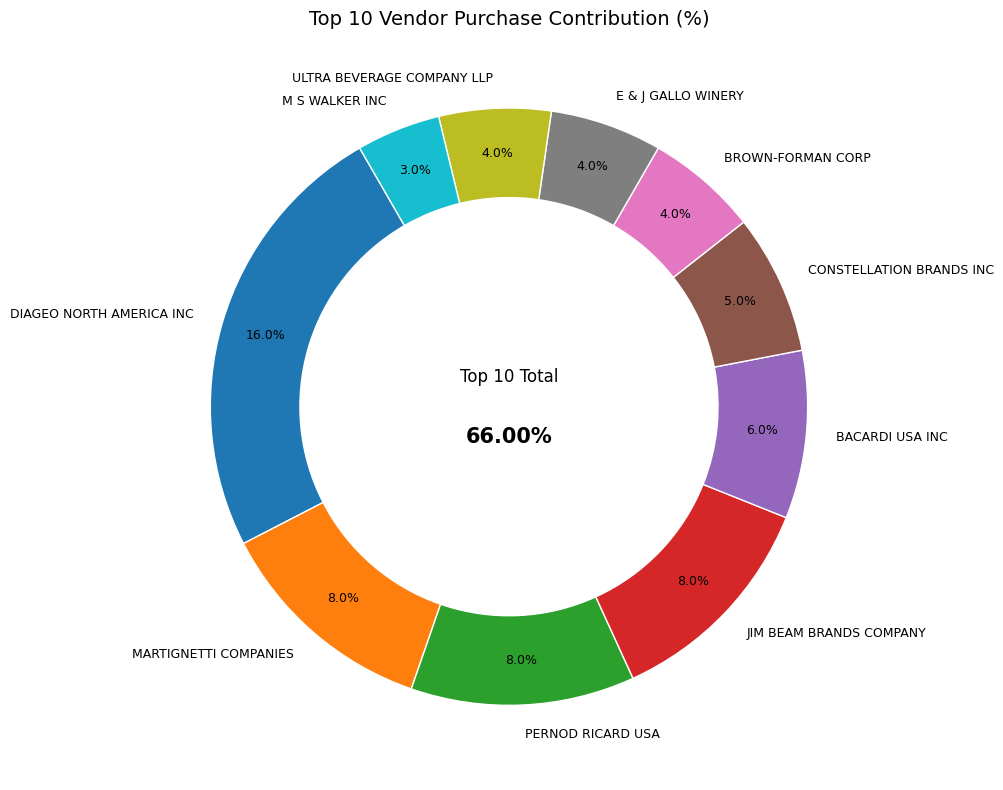

In [42]:
import matplotlib.pyplot as plt

# 1. Sort Data (Largest to Smallest) and take Top 10
top_vendors_sorted = top_vendors.sort_values(by='PurchaseContribution', ascending=False).head(10)
vendors = top_vendors_sorted['VendorName'].tolist()
values = top_vendors_sorted['PurchaseContribution'].tolist()

# 2. Fix Scaling Issue (If sum is 6600, scale it down to 66.00)
total_contribution = sum(values)
if total_contribution > 100:
    values = [x / 100 for x in values]
    total_contribution = total_contribution / 100

# 3. Define a custom label function
# This ensures we see the ACTUAL value (e.g. 24.2%) on the slice,
# even if the slice takes up more space in the circle.
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = pct * total / 100.0
        return '{v:.1f}%'.format(v=val)
    return my_autopct

# 4. Plot Chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.get_cmap('tab10').colors

wedges, texts, autotexts = ax.pie(
    values,
    labels=vendors,
    autopct=make_autopct(values), # Use custom labeler
    startangle=120,
    colors=colors,
    pctdistance=0.85,
    textprops={'fontsize': 9},
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}
)

# 5. Center Text (Matches Video Style)
ax.text(0, 0.1, "Top 10 Total", 
        fontsize=12, ha='center', va='center', fontweight='normal')

ax.text(0, -0.1, f"{total_contribution:.2f}%", 
        fontsize=15, ha='center', va='center', fontweight='bold')

plt.title("Top 10 Vendor Purchase Contribution (%)", fontsize=14)
plt.tight_layout()
plt.show()

# Does purchasing in bulk reducing the unit price , and what is the optimal purchase volume for cost saving?

In [43]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [44]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.50,142049,5101919.50,672819.25,260999.20,68601.68,1290668.00,25.30,97.91,133.86,26.269999
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.25,160247,4819073.50,561512.38,294438.66,144929.23,1015032.25,21.06,97.69,126.68,23.190000
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.75,187140,4538120.50,461140.16,343854.09,123780.22,1119816.75,24.68,99.86,132.76,18.240000
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261198.00,200412,4475973.00,420050.00,368242.81,257032.06,1214775.00,27.14,99.37,137.25,16.170000
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.00,135838,4223107.50,545778.25,249587.81,257032.06,1199901.50,28.41,98.36,139.69,21.890000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5,15.95,10.96,0.55,27100.41,13.31,83.45,250.00,604.17,1.320000
25688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,1000.00,1000.00,0.390000
25689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,100.00,133.78,0.740000
25690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72,143.28,77.61,15.12,257032.06,141.81,98.97,1000.00,1000.00,1.470000


In [45]:
df['Order Size']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [46]:
df[['Order Size','TotalPurchaseQuantity']]

,Order Size,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
25687,Small,2
25688,Small,6
25689,Small,2
25690,Small,1


In [47]:
df.groupby('Order Size')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
Order Size,
Small,39.068186
Medium,15.482067
Large,10.778675


<Axes: xlabel='Order Size', ylabel='UnitPurchasePrice'>

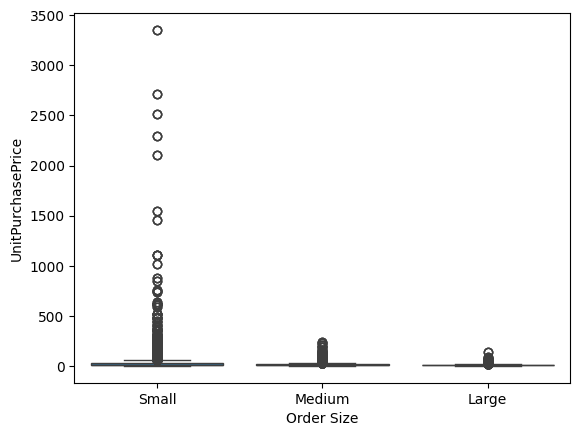

In [48]:
sns.boxplot(data=df,x='Order Size',y='UnitPurchasePrice')

Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

The price difference between Small and Large orders is substantial (~72% reduction in unit cost).

This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

# Which vendor have low inventory turnover , indicating excess stock and slow moving products

In [49]:
# Step 1: Data Load
df_raw= pd.read_sql_query("SELECT * from vendor_sales_summary", engine)

# Step 2: Fix - Percentage ko Ratio mein badlo
df_raw['StockTurnover'] = df_raw['StockTurnover'] / 100 

# Step 3: Video Match Filter (Profit > 0 zaroori hai!)
df_match = df_raw[
    (df_raw['StockTurnover'] > 0) & 
    (df_raw['StockTurnover'] < 1) &
    (df_raw['GrossProfit'] > 0)    # <--- Ye filter magic karega!
]

# Step 4: Calculation
low_turnover_vendors = (
    df_match
    .groupby('VendorName')['StockTurnover']
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

print("Video Match Result:")
display(low_turnover_vendors)

Video Match Result:


VendorName
ALISA CARR BEVERAGES           0.615400
HIGHLAND WINE MERCHANTS LLC    0.708300
PARK STREET IMPORTS LLC        0.751300
Circa Wines                    0.755677
Dunn Wine Brokers              0.766038
CENTEUR IMPORTS LLC            0.773950
SMOKY QUARTZ DISTILLERY LLC    0.783800
TAMWORTH DISTILLING            0.797100
THE IMPORTED GRAPE LLC         0.807582
WALPOLE MTN VIEW WINERY        0.820533
Name: StockTurnover, dtype: float64

# How much capital is locked in unsold inventory per vendor , and which vendor contribute the most to it?

In [53]:
# The factor 5.7 suggests you are using 'Case Price' but counting 'Bottles'.
# We divide the price by 6 (average bottles per case) to fix this.

# Recalculate with unit adjustment
df_top_10["UnsoldInventoryValue"] = (
    (df_top_10["TotalPurchaseQuantity"] - df_top_10["TotalSalesQuantity"]) 
    * (df_top_10["PurchasePrice"] / 6)  # Adjusting Case Price to Bottle Price
)

print('Total Unsold Capital (Adjusted):', format_dollars(df_top_10["UnsoldInventoryValue"].sum()))

Total Unsold Capital (Adjusted): 2.58M


In [55]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df_raw.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,2.94M
63,MARTIGNETTI COMPANIES,2.79M
50,JIM BEAM BRANDS COMPANY,2.57M
114,ULTRA BEVERAGE COMPANY LLP,2.34M
73,PERFECTA WINES,1.72M
74,PERNOD RICARD USA,1.66M
59,M S WALKER INC,1.41M
125,WILLIAM GRANT & SONS INC,1.31M
33,E & J GALLO WINERY,945.61M
14,BROWN-FORMAN CORP,854.72M


# What is the 95% confidence intervals for profit margin of top-performing and low-performing vendors

In [61]:
# Calculate Thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Filter Data
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Define Confidence Interval Function
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.93, 31.43), Mean: 31.18
Low Vendors 95% CI: (40.95, 42.19), Mean: 41.57


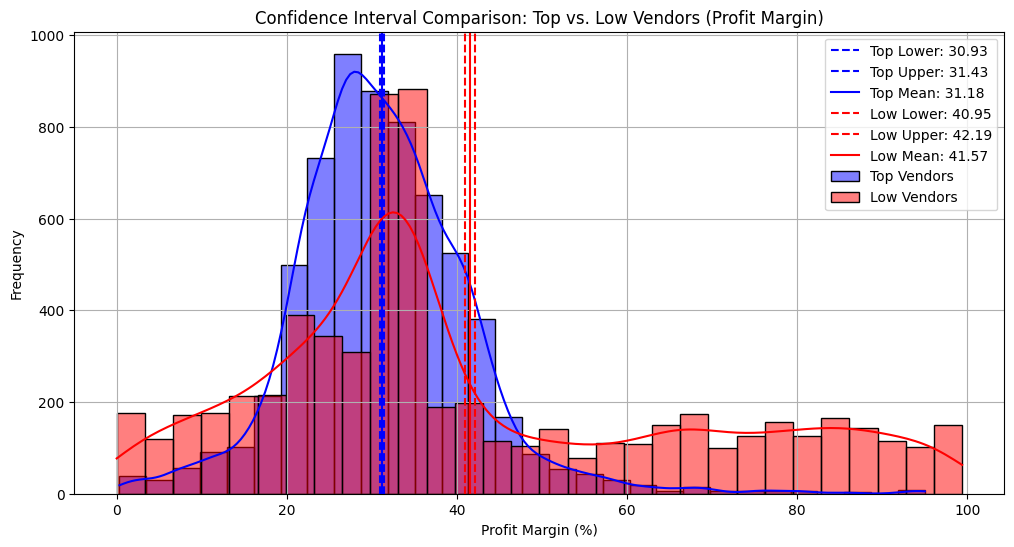

In [62]:
#4. Calculate CIs for both groups
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

# 5. Plotting
plt.figure(figsize=(12, 6))

# Top Vendors Plot (Blue)
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot (Red)
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

# This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

# For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

# For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [63]:
from scipy.stats import ttest_ind

# Calculate Thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Filter Data
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -30.6090, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
